# **E - commerce**

In [ ]:
# date 15 Jan 2026

# Task :
#### 1. Data Cleaning and Exploratory Data Analysis (EDA)
#### 2. Customer Segmentation using RFM analysis ***************************************
#### 3. Customer Segmentation using K-Means, Hierarchical and DBSCAN
#### 4. Analysis of customer retention rates using Cohort Analysis *********************

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/E-com_Data.csv')
df.head()

,CustomerID,Item Code,InvoieNo,Date of purchase,Quantity,Time,price per Unit,Price,Shipping Location,Cancelled_status,Reason of return,Sold as set
0,4355.0,15734,398177.0,29-10-2017,6.0,3:36:00 PM,321.0,1926.0,Location 1,NaN,NaN,NaN
1,4352.0,14616,394422.0,05-10-2017,2.0,2:53:00 PM,870.0,1740.0,Location 1,NaN,NaN,NaN
2,4352.0,14614,394422.0,12-10-2017,2.0,2:53:00 PM,933.0,1866.0,Location 1,NaN,NaN,NaN
3,4352.0,85014B,388633.0,22-08-2017,3.0,2:47:00 PM,623.0,1869.0,Location 1,NaN,NaN,NaN
4,4352.0,15364,394422.0,10-10-2017,2.0,2:53:00 PM,944.0,1888.0,Location 1,NaN,NaN,NaN


# Part 1 : Data Cleaning and EDA

#### a) Identifying missing values and noise in the dataset
#### b) Cleaning and visualizing the data
#### b) Conducting analyses by invoice, product, other variable

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541116 entries, 0 to 541115
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         404189 non-null  float64
 1   Item Code          537979 non-null  object 
 2   InvoieNo           537979 non-null  float64
 3   Date of purchase   537979 non-null  object 
 4   Quantity           537979 non-null  float64
 5   Time               537979 non-null  object 
 6   price per Unit     537979 non-null  float64
 7   Price              537979 non-null  float64
 8   Shipping Location  537979 non-null  object 
 9   Cancelled_status   8345 non-null    object 
 10  Reason of return   3 non-null       object 
 11  Sold as set        0 non-null       float64
dtypes: float64(6), object(6)
memory usage: 49.5+ MB


In [ ]:
# CustomerID  - Mandatory
# InvoieNo - Frequency
# Date of purchase - Recency
# Price - Monetory

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,404189.0,2181.909035,1252.681881,2.0,1207.0,2078.0,3291.0,4372.0
InvoieNo,537979.0,385017.572063,13426.052649,361429.0,372961.0,385706.0,396873.0,406651.0
Quantity,537979.0,9.343339,27.623322,-2003.0,1.0,3.0,10.0,3186.0
price per Unit,537979.0,378.339062,440.048823,1.0,169.0,261.0,456.0,64973.0
Price,537979.0,2161.414593,4538.487177,-10152.0,451.0,1194.0,2232.0,90400.0
Sold as set,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.columns

Index(['CustomerID', 'Item Code', 'InvoieNo', 'Date of purchase', 'Quantity',
       'Time', 'price per Unit', 'Price', 'Shipping Location',
       'Cancelled_status', 'Reason of return', 'Sold as set'],
      dtype='object')

In [ ]:
drop_columns = ['Item Code','Quantity','Time', 'price per Unit','Shipping Location','Cancelled_status', 'Reason of return', 'Sold as set']

df.drop(drop_columns, axis=1, inplace = True)

In [ ]:
df.head()

,CustomerID,InvoieNo,Date of purchase,Price
0,4355.0,398177.0,29-10-2017,1926.0
1,4352.0,394422.0,05-10-2017,1740.0
2,4352.0,394422.0,12-10-2017,1866.0
3,4352.0,388633.0,22-08-2017,1869.0
4,4352.0,394422.0,10-10-2017,1888.0


In [ ]:
df.duplicated().sum()

np.int64(6008)

In [ ]:
df.drop_duplicates(inplace = True)

In [ ]:
df.Price.min()

-10152.0

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,402859.0,2182.187224,1252.636483,2.0,1207.0,2078.0,3291.0,4372.0
InvoieNo,535107.0,385009.702116,13418.210488,361429.0,372964.0,385665.0,396811.0,406651.0
Price,535107.0,2167.848915,4547.338495,-10152.0,453.0,1200.0,2236.0,90400.0


In [ ]:
df.head(2)

,CustomerID,InvoieNo,Date of purchase,Price
0,4355.0,398177.0,29-10-2017,1926.0
1,4352.0,394422.0,05-10-2017,1740.0


In [ ]:
df.isnull().sum()/len(df)*100

,0
CustomerID,24.714450
InvoieNo,0.000187
Date of purchase,0.000187
Price,0.000187


In [ ]:
df.isnull().sum()

,0
CustomerID,132249
InvoieNo,1
Date of purchase,1
Price,1


In [ ]:
def missing_values(df):
    missing_number = df.isnull().sum().sort_values(ascending=False)
    missing_percent = (df.isnull().sum()/ df.isnull().count()).sort_values(ascending=False)
    missing_values = pd.concat([missing_number, missing_percent], axis=1, keys=["missing_number","missing_percent"])
    return missing_values[missing_values["missing_number"]>0]
missing_values(df)

,missing_number,missing_percent
CustomerID,132249,0.247145
InvoieNo,1,0.000002
Date of purchase,1,0.000002
Price,1,0.000002


In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
CustomerID,132249
InvoieNo,1
Date of purchase,1
Price,1


In [ ]:
(df.isnull().sum()/ df.isnull().count()).sort_values(ascending=False)

,0
CustomerID,0.247145
InvoieNo,0.000002
Date of purchase,0.000002
Price,0.000002


In [ ]:
df.shape

(535108, 4)

In [ ]:
df = df.dropna(subset=['CustomerID'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 402859 entries, 0 to 537949
Data columns (total 4 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   CustomerID        402859 non-null  float64
 1   InvoieNo          402859 non-null  float64
 2   Date of purchase  402859 non-null  object 
 3   Price             402859 non-null  float64
dtypes: float64(3), object(1)
memory usage: 15.4+ MB


In [ ]:
(df.isnull().sum()/ df.isnull().count()).sort_values(ascending=False)

,0
CustomerID,0.0
InvoieNo,0.0
Date of purchase,0.0
Price,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 402859 entries, 0 to 537949
Data columns (total 4 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   CustomerID        402859 non-null  float64
 1   InvoieNo          402859 non-null  float64
 2   Date of purchase  402859 non-null  object 
 3   Price             402859 non-null  float64
dtypes: float64(3), object(1)
memory usage: 15.4+ MB


In [ ]:
import datetime
df['Date of purchase'] = pd.to_datetime(df['Date of purchase'])

In [ ]:
df = df.rename( columns = {'InvoieNo':'InvoiceNo', 'Date of purchase': 'Date'})

In [ ]:
df.head()

,CustomerID,InvoiceNo,Date,Price
0,4355.0,398177.0,2017-10-29,1926.0
1,4352.0,394422.0,2017-10-05,1740.0
2,4352.0,394422.0,2017-10-12,1866.0
3,4352.0,388633.0,2017-08-22,1869.0
4,4352.0,394422.0,2017-10-10,1888.0


In [ ]:
df['Date'].describe().T

,Date
count,402859
mean,2017-07-15 14:25:02.538605056
min,2016-12-02 00:00:00
25%,2017-04-12 00:00:00
50%,2017-08-05 00:00:00
75%,2017-10-26 00:00:00
max,2017-12-19 00:00:00


In [ ]:
df['CustomerID'].nunique()

4349

In [ ]:
df.shape

(402859, 4)

In [ ]:
df['CustomerID'].count()

np.int64(402859)

In [ ]:
new_date = datetime.datetime(2017, 12,20)
new_date

datetime.datetime(2017, 12, 20, 0, 0)

In [ ]:
df['CustomerID']==4352.0

,CustomerID
0,False
1,True
2,True
3,True
4,True
...,...
537945,False
537946,False
537947,False
537948,False


In [ ]:
a= (df['CustomerID']==4352.0)
a.count()

np.int64(402859)

In [ ]:
a.value_counts()

,count
CustomerID,
False,402738
True,121


# Customer Segmentation using RFM analysis

##### **RFM Analysis** : is a marketing techniques and method used to evaluate customer behavior
###### RFM stands for **Recency**, **Frequency**, and **Monetary**

- **Recency:** Indicates how recently a customer has made a purchase. Customer who have purchased more recently have a higher recency score.
- **Frequency:** Represents how many times a customer has made a purchase within a specific time period(typically within a year). Customer who
purchase more frequently have a higher frequency score

- **Monetary:** Refers to the total amount a customer has spent within a specific time period. Customer who spend more have a higher monetary score.

- A Score of **5** represent the best customers (most recent, most frequent, and highest spending)
- A score of **1** represent the lease engaged customers.

- **Prime (vip) Customers**
- **Loyal customers**
- **Potential customer**

In [ ]:
RFMApproch1 = df.groupby('CustomerID').agg({'Date': lambda x: (new_date - x.max()).days,
                                            'InvoiceNo': lambda x: x.count(),
                                            'Price': lambda x: x.sum() })                         # 1st ?

In [ ]:
RFMApproch1

,Date,InvoiceNo,Price
CustomerID,,,
2.0,4,181,550416.0
3.0,77,27,257404.0
4.0,19,72,176613.0
5.0,311,16,41976.0
6.0,37,84,151822.0
...,...,...,...
4368.0,278,10,20480.0
4369.0,181,7,10774.0
4370.0,9,13,24962.0


In [ ]:
RFMApproch1.rename(columns = {'Date':'Recency', 'InvoiceNo':'Frequency','Price':'Monetary'}, inplace=True)
RFMApproch1.reset_index(inplace=True)
RFMApproch1

,CustomerID,Recency,Frequency,Monetary
0,2.0,4,181,550416.0
1,3.0,77,27,257404.0
2,4.0,19,72,176613.0
3,5.0,311,16,41976.0
4,6.0,37,84,151822.0
...,...,...,...,...
4344,4368.0,278,10,20480.0
4345,4369.0,181,7,10774.0
4346,4370.0,9,13,24962.0
4347,4371.0,4,751,279720.0


In [ ]:
RFMApproch1.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,4349.0,2187.093355,1261.544319,2.0,1095.0,2186.0,3279.0,4372.0
Recency,4349.0,93.299379,100.701315,1.0,18.0,51.0,144.0,381.0
Frequency,4349.0,92.632559,230.742279,1.0,17.0,42.0,101.0,7919.0
Monetary,4349.0,229493.932881,855668.518674,-50372.0,38140.0,83635.0,205444.0,35472089.0


In [ ]:
RFMApproch1.head(3)

,CustomerID,Recency,Frequency,Monetary
0,2.0,4,181,550416.0
1,3.0,77,27,257404.0
2,4.0,19,72,176613.0


# Split data into 4 Segment basis on quantile method

In [ ]:
quantiles = RFMApproch1.quantile(q=[0.25, 0.50, 0.75])
quantiles = quantiles.to_dict()
quantiles

{'CustomerID': {0.25: 1095.0, 0.5: 2186.0, 0.75: 3279.0},
 'Recency': {0.25: 18.0, 0.5: 51.0, 0.75: 144.0},
 'Frequency': {0.25: 17.0, 0.5: 42.0, 0.75: 101.0},
 'Monetary': {0.25: 38140.0, 0.5: 83635.0, 0.75: 205444.0}}

In [ ]:
RFMApproch1

,CustomerID,Recency,Frequency,Monetary
0,2.0,4,181,550416.0
1,3.0,77,27,257404.0
2,4.0,19,72,176613.0
3,5.0,311,16,41976.0
4,6.0,37,84,151822.0
...,...,...,...,...
4344,4368.0,278,10,20480.0
4345,4369.0,181,7,10774.0
4346,4370.0,9,13,24962.0
4347,4371.0,4,751,279720.0


In [ ]:
quantiles = RFMApproch1.quantile(q=[0.25, 0.50, 0.75])
quantiles = quantiles.to_dict()
quantiles

{'CustomerID': {0.25: 1095.0, 0.5: 2186.0, 0.75: 3279.0},
 'Recency': {0.25: 18.0, 0.5: 51.0, 0.75: 144.0},
 'Frequency': {0.25: 17.0, 0.5: 42.0, 0.75: 101.0},
 'Monetary': {0.25: 38140.0, 0.5: 83635.0, 0.75: 205444.0}}

In [ ]:
# def Recency_value(x, c, quantiles):      #each value in Recency --  quantiles['Recency'][0.25]

def Recency_value(x, p, d):
    if x <= d[p][0.25]:
       return 1
    elif x <= d[p][0.5]:
       return 2
    elif x <= d[p][0.75]:
       return 3
    else :
       return 4

In [ ]:
RFMApproch1['R'] = RFMApproch1['Recency'].apply(Recency_value, args = ('Recency', quantiles))

In [ ]:
RFMApproch1['R']

,R
0,1
1,3
2,2
3,4
4,2
...,...
4344,4
4345,4
4346,1
4347,1


In [ ]:
def Freq_Mont_value(x,p,d):
    if x <= d[p][0.25]:
       return 4
    elif x <= d[p][0.5]:
       return 3
       return 2
    else :
       return 1

In [ ]:
RFMApproch1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4349 entries, 0 to 4348
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  4349 non-null   float64
 1   Recency     4349 non-null   int64  
 2   Frequency   4349 non-null   int64  
 3   Monetary    4349 non-null   float64
 4   R           4349 non-null   int64  
dtypes: float64(2), int64(3)
memory usage: 170.0 KB


In [ ]:
RFMApproch1['F'] = RFMApproch1['Frequency'].apply(Freq_Mont_value, args = ['Frequency', quantiles])

In [ ]:
RFMApproch1.reset_index()

,index,CustomerID,Recency,Frequency,Monetary,R,F
0,0,2.0,4,181,550416.0,1,1
1,1,3.0,77,27,257404.0,3,3
2,2,4.0,19,72,176613.0,2,1
3,3,5.0,311,16,41976.0,4,4
4,4,6.0,37,84,151822.0,2,1
...,...,...,...,...,...,...,...
4344,4344,4368.0,278,10,20480.0,4,4
4345,4345,4369.0,181,7,10774.0,4,4
4346,4346,4370.0,9,13,24962.0,1,4
4347,4347,4371.0,4,751,279720.0,1,1


In [ ]:
RFMApproch1['M'] = RFMApproch1['Monetary'].apply(Freq_Mont_value, args = ('Monetary', quantiles))

In [ ]:
RFMApproch1

,CustomerID,Recency,Frequency,Monetary,R,F,M
0,2.0,4,181,550416.0,1,1,1
1,3.0,77,27,257404.0,3,3,1
2,4.0,19,72,176613.0,2,1,1
3,5.0,311,16,41976.0,4,4,3
4,6.0,37,84,151822.0,2,1,1
...,...,...,...,...,...,...,...
4344,4368.0,278,10,20480.0,4,4,4
4345,4369.0,181,7,10774.0,4,4,4
4346,4370.0,9,13,24962.0,1,4,4
4347,4371.0,4,751,279720.0,1,1,1


In [ ]:
RFMApproch1['RFM'] = RFMApproch1[['R', 'F', 'M']].sum(axis=1)

In [ ]:
RFMApproch1

,CustomerID,Recency,Frequency,Monetary,R,F,M,RFM
0,2.0,4,181,550416.0,1,1,1,3
1,3.0,77,27,257404.0,3,3,1,7
2,4.0,19,72,176613.0,2,1,1,4
3,5.0,311,16,41976.0,4,4,3,11
4,6.0,37,84,151822.0,2,1,1,4
...,...,...,...,...,...,...,...,...
4344,4368.0,278,10,20480.0,4,4,4,12
4345,4369.0,181,7,10774.0,4,4,4,12
4346,4370.0,9,13,24962.0,1,4,4,9
4347,4371.0,4,751,279720.0,1,1,1,3


In [ ]:
RFMApproch1.reset_index()

,index,CustomerID,Recency,Frequency,Monetary,R,F,M,RFM
0,0,2.0,4,181,550416.0,1,1,1,3
1,1,3.0,77,27,257404.0,3,3,1,7
2,2,4.0,19,72,176613.0,2,1,1,4
3,3,5.0,311,16,41976.0,4,4,3,11
4,4,6.0,37,84,151822.0,2,1,1,4
...,...,...,...,...,...,...,...,...,...
4344,4344,4368.0,278,10,20480.0,4,4,4,12
4345,4345,4369.0,181,7,10774.0,4,4,4,12
4346,4346,4370.0,9,13,24962.0,1,4,4,9
4347,4347,4371.0,4,751,279720.0,1,1,1,3


In [ ]:
RFMApproch1.to_csv('RFMApproch1.csv')

In [ ]:
RFMApproch1['RFM'].value_counts()

,count
RFM,
3,789
4,519
5,486
10,456
12,410
11,380
9,372
8,342
6,313


In [ ]:
Loyality_level = ['platinum', 'gold', 'silver', 'bronze']
score_cuts = pd.qcut(RFMApproch1.RFM, q=4, labels = Loyality_level)

In [ ]:
score_cuts

,RFM
0,platinum
1,gold
2,platinum
3,bronze
4,platinum
...,...
4344,bronze
4345,bronze
4346,silver
4347,platinum


In [ ]:
RFMApproch1

,CustomerID,Recency,Frequency,Monetary,R,F,M,RFM
0,2.0,4,181,550416.0,1,1,1,3
1,3.0,77,27,257404.0,3,3,1,7
2,4.0,19,72,176613.0,2,1,1,4
3,5.0,311,16,41976.0,4,4,3,11
4,6.0,37,84,151822.0,2,1,1,4
...,...,...,...,...,...,...,...,...
4344,4368.0,278,10,20480.0,4,4,4,12
4345,4369.0,181,7,10774.0,4,4,4,12
4346,4370.0,9,13,24962.0,1,4,4,9
4347,4371.0,4,751,279720.0,1,1,1,3


In [ ]:
score_cuts.values

['platinum', 'gold', 'platinum', 'bronze', 'platinum', ..., 'bronze', 'bronze', 'silver', 'platinum', 'platinum']
Length: 4349
Categories (4, object): ['platinum' < 'gold' < 'silver' < 'bronze']

In [ ]:
RFMApproch1['Loyality_level'] = score_cuts.values

In [ ]:
RFMApproch1['Loyality_level'] = score_cuts.values

In [ ]:
RFMApproch1

,CustomerID,Recency,Frequency,Monetary,R,F,M,RFM,Loyality_level
0,2.0,4,181,550416.0,1,1,1,3,platinum
1,3.0,77,27,257404.0,3,3,1,7,gold
2,4.0,19,72,176613.0,2,1,1,4,platinum
3,5.0,311,16,41976.0,4,4,3,11,bronze
4,6.0,37,84,151822.0,2,1,1,4,platinum
...,...,...,...,...,...,...,...,...,...
4344,4368.0,278,10,20480.0,4,4,4,12,bronze
4345,4369.0,181,7,10774.0,4,4,4,12,bronze
4346,4370.0,9,13,24962.0,1,4,4,9,silver
4347,4371.0,4,751,279720.0,1,1,1,3,platinum


In [ ]:
RFMApproch1 = RFMApproch1.reset_index()
RFMApproch1

,index,CustomerID,Recency,Frequency,Monetary,R,F,M,RFM,Loyality_level
0,0,2.0,4,181,550416.0,1,1,1,3,platinum
1,1,3.0,77,27,257404.0,3,3,1,7,gold
2,2,4.0,19,72,176613.0,2,1,1,4,platinum
3,3,5.0,311,16,41976.0,4,4,3,11,bronze
4,4,6.0,37,84,151822.0,2,1,1,4,platinum
...,...,...,...,...,...,...,...,...,...,...
4344,4344,4368.0,278,10,20480.0,4,4,4,12,bronze
4345,4345,4369.0,181,7,10774.0,4,4,4,12,bronze
4346,4346,4370.0,9,13,24962.0,1,4,4,9,silver
4347,4347,4371.0,4,751,279720.0,1,1,1,3,platinum


In [ ]:
RFMApproch1.shape       # need customer id

(4349, 10)

In [ ]:
RFMApproch1['Loyality_level'].value_counts()

,count
Loyality_level,
platinum,1308
silver,1170
gold,1081
bronze,790


In [ ]:
RFMApproch1.to_csv('Loyality_Level.csv')

In [ ]:
RFMApproch1.columns

Index(['index', 'CustomerID', 'Recency', 'Frequency', 'Monetary', 'R', 'F',
       'M', 'RFM', 'Loyality_level'],
      dtype='object')

In [ ]:
final_report = RFMApproch1.groupby('Loyality_level')[['Recency', 'Frequency', 'Monetary', 'CustomerID']].agg({'Recency': 'sum', 'Frequency':'sum',
                                                                                                              'Monetary': 'sum',
                                                                                                               'CustomerID': 'nunique'})

In [ ]:
final_report

,Recency,Frequency,Monetary,CustomerID
Loyality_level,,,,
platinum,22759,284717,735146515.0,1308
gold,79083,80173,178440603.0,1081
silver,129985,29381,65938350.1,1170
bronze,173932,8588,18543646.0,790


In [ ]:
final_report.reset_index()

,Loyality_level,Recency,Frequency,Monetary,CustomerID
0,platinum,22759,284717,735146515.0,1308
1,gold,79083,80173,178440603.0,1081
2,silver,129985,29381,65938350.1,1170
3,bronze,173932,8588,18543646.0,790


In [ ]:
final_report

,Recency,Frequency,Monetary,CustomerID
Loyality_level,,,,
platinum,22759,284717,735146515.0,1308
gold,79083,80173,178440603.0,1081
silver,129985,29381,65938350.1,1170
bronze,173932,8588,18543646.0,790


In [ ]:
final_report = final_report.rename(columns = { 'CustomerID': 'NumBuyers'})
final_report.reset_index(inplace = True)

In [ ]:
final_report

,Loyality_level,Recency,Frequency,Monetary,NumBuyers
0,platinum,22759,284717,735146515.0,1308
1,gold,79083,80173,178440603.0,1081
2,silver,129985,29381,65938350.1,1170
3,bronze,173932,8588,18543646.0,790


In [ ]:
final_report['Percent'] = round(final_report['NumBuyers'] / final_report['NumBuyers'].sum()*100,2)

In [ ]:
final_report

,Loyality_level,Recency,Frequency,Monetary,NumBuyers,Percent
0,platinum,22759,284717,735146515.0,1308,30.08
1,gold,79083,80173,178440603.0,1081,24.86
2,silver,129985,29381,65938350.1,1170,26.90
3,bronze,173932,8588,18543646.0,790,18.17


In [ ]:
final_report['NumBuyers']

,NumBuyers
0,1308
1,1081
2,1170
3,790


In [ ]:
final_report['NumBuyers'].sum()

np.int64(4349)

In [ ]:
final_report['NumBuyers'] / final_report['NumBuyers'].sum()*100

,NumBuyers
0,30.075880
1,24.856289
2,26.902736
3,18.165095


In [ ]:
final_report

,Loyality_level,Recency,Frequency,Monetary,NumBuyers,Percent
0,platinum,22759,284717,735146515.0,1308,30.08
1,gold,79083,80173,178440603.0,1081,24.86
2,silver,129985,29381,65938350.1,1170,26.90
3,bronze,173932,8588,18543646.0,790,18.17


In [ ]:
final_report_1 = final_report[['Loyality_level', 'NumBuyers', 'Percent']]
final_report_1

,Loyality_level,NumBuyers,Percent
0,platinum,1308,30.08
1,gold,1081,24.86
2,silver,1170,26.90
3,bronze,790,18.17


In [ ]:
pip install squarify


### What is squarify?

squarify is a Python library used to create treemap visualizations, often used in:

RFM Analysis

Market segmentation

Sales / Customer distribution

Hierarchical data

<Axes: >

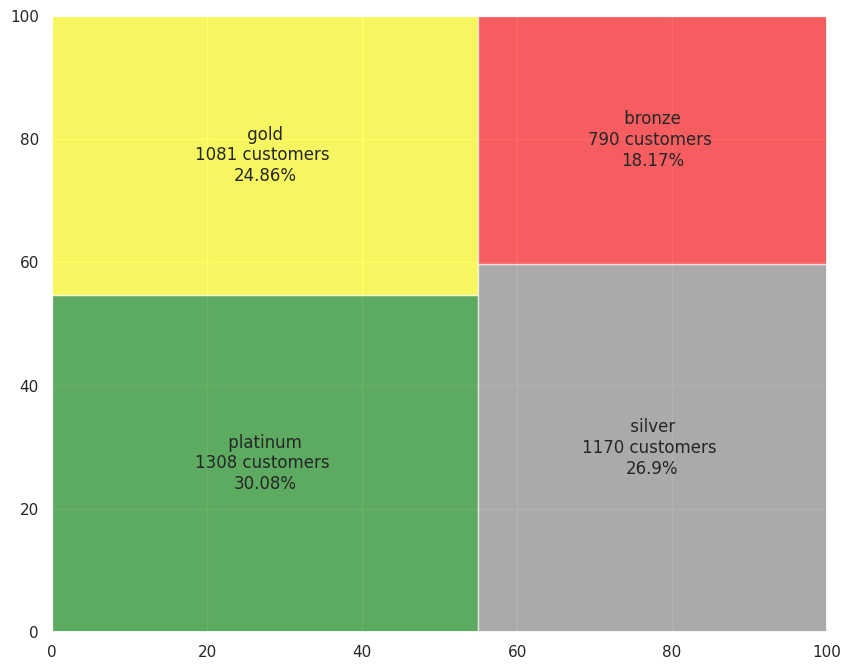

In [ ]:
import squarify

fig = plt.gcf()
ax = fig.add_subplot()

fig.set_size_inches(10,8)

colors_dics = {'plantinum': 'green', 'gold':'yellow', 'silver': 'grey', 'bronze': 'red'}

squarify.plot(sizes = final_report_1['NumBuyers'], color = colors_dics.values(),
              label = [' {} \n{:0.0f} customers \n{}%'.format(*final_report_1.iloc[i]) for i in range(0, len(final_report_1))], alpha = 0.6)  # label loop  ??

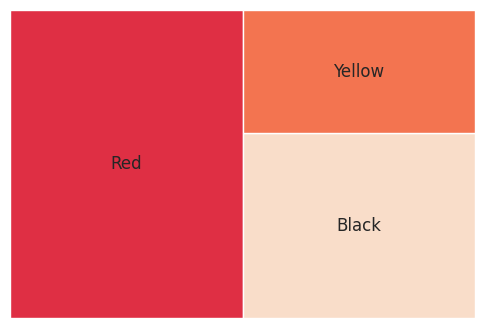

In [ ]:
import matplotlib.pyplot as plt
import squarify

sizes1 = [50, 30, 20]
labels1 = ['Red', 'Black', 'Yellow']

plt.figure(figsize=(6,4))
squarify.plot(sizes=sizes1, label=labels1)
plt.axis('off')
plt.show()

<Axes: >

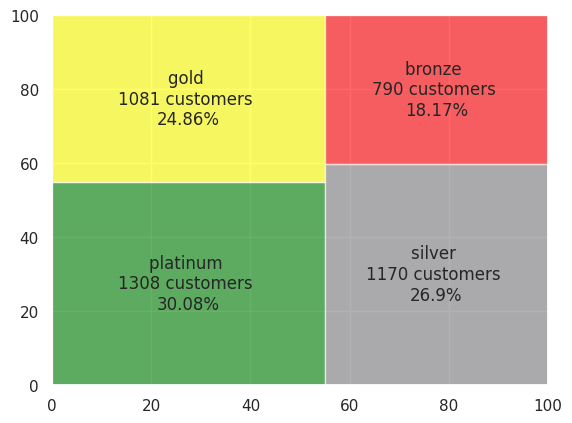

In [ ]:

colors_dics = {'platinum':'green', 'gold':'yellow', 'silver':'gray', 'bronze':'red'}

squarify.plot(sizes=final_report_1['NumBuyers'], color = colors_dics.values(),
              label = ['{} \n{:0.0f} customers \n{}%'.format(*final_report_1.iloc[i]) for i in range(0, len(final_report_1))], alpha=0.6)


AttributeError: Rectangle.set() got an unexpected keyword argument 'colors_dics'

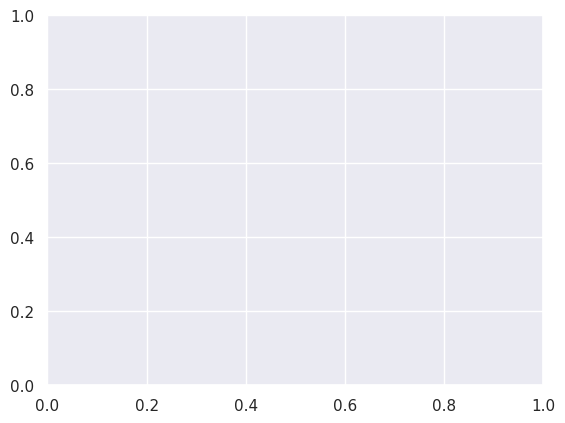

In [ ]:

squarify.plot(sizes=final_report_1['NumBuyers'] ,
             colors_dics = {'platinum':'green', 'gold':'yellow', 'silver':'gray', 'bronze':'red'}
 )


# UnSupervised Machine Learning - Segmentation / Clustering / Grouping

In [ ]:
# Importing Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import scipy.cluster.hierarchy as sch
from datetime import datetime

In [ ]:
RFMApproch1.head(3)

,index,CustomerID,Recency,Frequency,Monetary,R,F,M,RFM,Loyality_level
0,0,2.0,4,181,550416.0,1,1,1,3,platinum
1,1,3.0,77,27,257404.0,3,3,1,7,gold
2,2,4.0,19,72,176613.0,2,1,1,4,platinum


In [ ]:
RFMApproch1.columns

Index(['index', 'CustomerID', 'Recency', 'Frequency', 'Monetary', 'R', 'F',
       'M', 'RFM', 'Loyality_level'],
      dtype='object')

In [ ]:
rfm_df = RFMApproch1[['Recency', 'Frequency', 'Monetary']]
rfm_df.head()

,Recency,Frequency,Monetary
0,4,181,550416.0
1,77,27,257404.0
2,19,72,176613.0
3,311,16,41976.0
4,37,84,151822.0


In [ ]:
# Standarization

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_df)
rfm_scaled

array([[-0.88687668,  0.38301434,  0.37509732],
       [-0.16187726, -0.28447368,  0.0326216 ],
       [-0.73790419, -0.08942848, -0.06180783],
       ...,
       [-0.83721918, -0.34515441, -0.23905922],
       [-0.88687668,  2.85358691,  0.05870479],
       [-0.48961672, -0.10676583,  0.0320933 ]])

# Part 1 - Customer Segmentation (Kmeans)

Finding optimal clusters using Elbow Method

In [ ]:
from sklearn.cluster import KMeans, DBSCAN

In [ ]:
sse = []
for k in range(1,11):
   kmeans = KMeans(n_clusters = k, random_state = 42)
   kmeans.fit(rfm_scaled)
   sse.append(kmeans.inertia_)
print(sse)

[13047.000000000011, 9419.36728282147, 5469.861439141797, 4244.715795373854, 3265.7085557508994, 2805.441042909251, 1945.2303762696351, 1684.276992085129, 1524.179723616895, 1358.4087590559054]


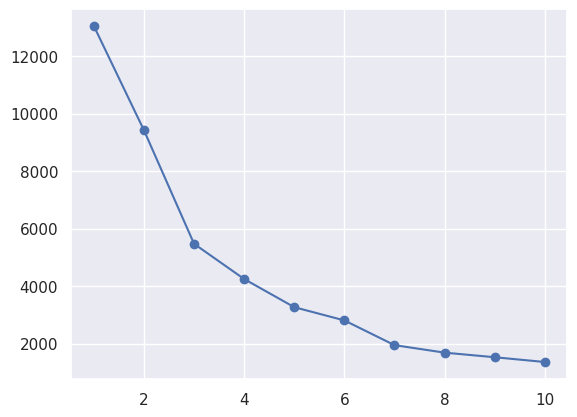

In [ ]:
plt.plot(range(1,11), sse, marker='o')
plt.show()

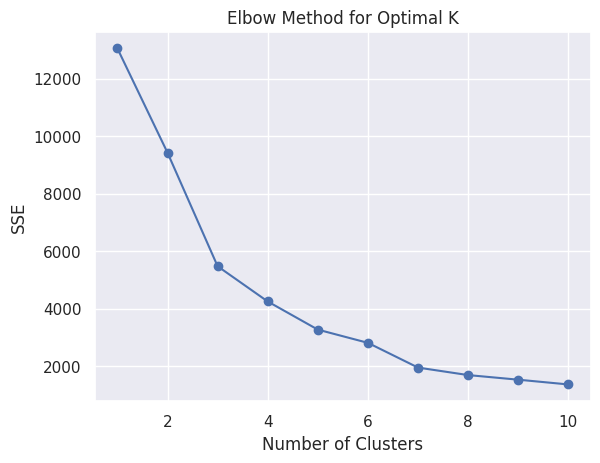

In [ ]:
plt.plot(range(1,11), sse, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('SSE')
plt.title("Elbow Method for Optimal K")
plt.show()

In [ ]:
Kmeans = KMeans(n_clusters = 5, random_state = 42)
rfm_df['KMeans_Cluster'] = Kmeans.fit_predict(rfm_scaled)

In [ ]:
rfm_df.head()

,Recency,Frequency,Monetary,KMeans_Cluster
0,4,181,550416.0,0
1,77,27,257404.0,0
2,19,72,176613.0,0
3,311,16,41976.0,1
4,37,84,151822.0,0


In [ ]:
rfm_df['KMeans_Cluster'].value_counts()

,count
KMeans_Cluster,
0,2920
1,1063
4,351
3,11
2,4


In [ ]:
rfm_scaled

AttributeError: 'numpy.ndarray' object has no attribute 'head'

# Hierarchical Clustering

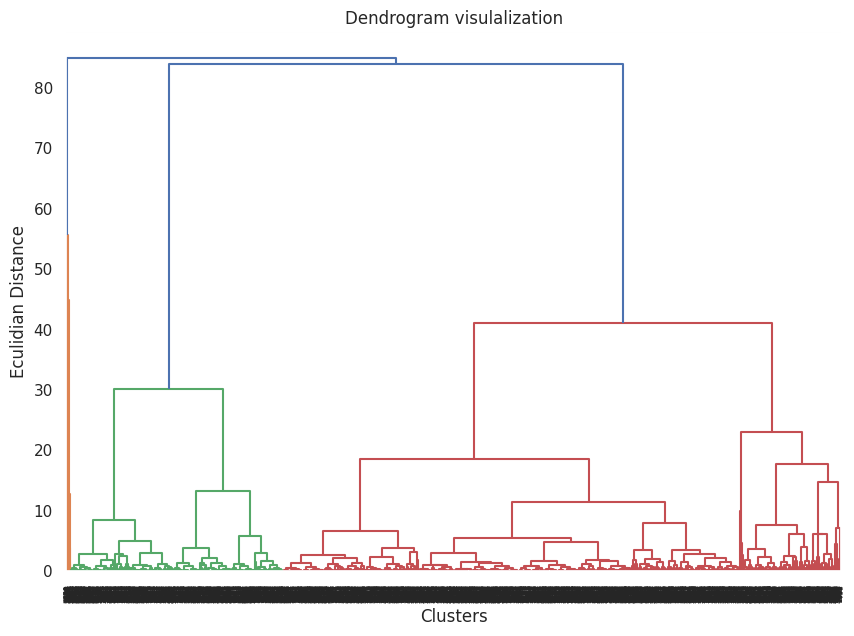

In [ ]:
linked = linkage(rfm_scaled, method = 'ward')   # ??

plt.figure(figsize=(10,7))
dendrogram(linked)
plt.title('Dendrogram visulalization')
plt.xlabel('Clusters')
plt.ylabel('Eculidian Distance')
plt.show()

In [ ]:
rfm_df['Hierarchical_Cluster'] = fcluster(linked, 6, criterion='maxclust')
rfm_df

# fcluster is used after hierarchical clustering to cut the dendrogram and assign final cluster labels to each data point.

,Recency,Frequency,Monetary,KMeans_Cluster,Hierarchical_Cluster
0,4,181,550416.0,0,6
1,77,27,257404.0,0,5
2,19,72,176613.0,0,5
3,311,16,41976.0,1,4
4,37,84,151822.0,0,5
...,...,...,...,...,...
4344,278,10,20480.0,1,4
4345,181,7,10774.0,1,4
4346,9,13,24962.0,0,5
4347,4,751,279720.0,4,6


In [ ]:
rfm_df['Hierarchical_Cluster']

,Hierarchical_Cluster
0,6
1,5
2,5
3,4
4,5
...,...
4344,4
4345,4
4346,5
4347,6


In [ ]:
rfm_df['Hierarchical_Cluster'].value_counts()

,count
Hierarchical_Cluster,
5,2564
4,1197
6,566
2,17
1,4
3,1


# Part 3 - DBSCAN

In [ ]:
dbscan = DBSCAN(eps = 1.5, min_samples = 5)
rfm_df['DBSCAN_Cluster'] = dbscan.fit_predict(rfm_scaled)
rfm_df

,Recency,Frequency,Monetary,KMeans_Cluster,Hierarchical_Cluster,DBSCAN_Cluster
0,4,181,550416.0,0,6,0
1,77,27,257404.0,0,5,0
2,19,72,176613.0,0,5,0
3,311,16,41976.0,1,4,0
4,37,84,151822.0,0,5,0
...,...,...,...,...,...,...
4344,278,10,20480.0,1,4,0
4345,181,7,10774.0,1,4,0
4346,9,13,24962.0,0,5,0
4347,4,751,279720.0,4,6,0


In [ ]:
rfm_df['DBSCAN_Cluster']==1

,DBSCAN_Cluster
0,False
1,False
2,False
3,False
4,False
...,...
4344,False
4345,False
4346,False
4347,False


In [ ]:
rfm_df['DBSCAN_Cluster'].value_counts()

,count
DBSCAN_Cluster,
0,4330
-1,19


# Cohort Anlysis for Customer Retension

In [ ]:
cohorts = ['Jan', 'Feb', 'Mar']
months = ['batch_one', 'batch_second', 'batch_third', 'batch_four']
retension_data = [[100,60,30,20], [100,70,40,25], [100,80,50,35]]


In [ ]:
retension_data

[[100, 60, 30, 20], [100, 70, 40, 25], [100, 80, 50, 35]]

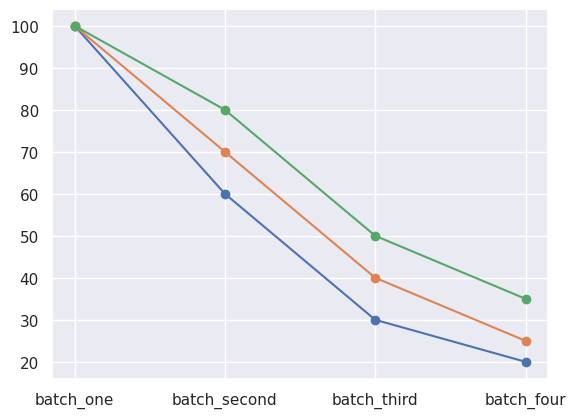

In [ ]:
for i, cohort in enumerate(cohorts):                               # ??
    plt.plot(months, retension_data[i], marker = 'o', label = cohort)
plt.show()

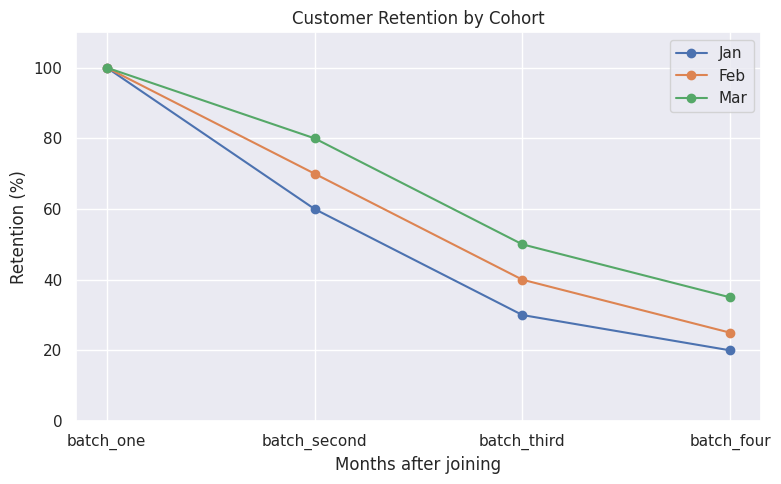

In [ ]:
cohorts = ['Jan','Feb','Mar']
months = ['batch_one','batch_second','batch_third','batch_four']
retention_data = [[100,60,30,20],[100,70,40,25],[100,80,50,35],]
plt.figure(figsize=(8,5))
for i, cohort in enumerate(cohorts):
    plt.plot(months, retention_data[i], marker='o', label=cohort)


plt.title("Customer Retention by Cohort")
plt.xlabel("Months after joining")
plt.ylabel("Retention (%)")
plt.ylim(0,110)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
df.head()

,CustomerID,InvoiceNo,Date,Price
0,4355.0,398177.0,2017-10-29,1926.0
1,4352.0,394422.0,2017-10-05,1740.0
2,4352.0,394422.0,2017-10-12,1866.0
3,4352.0,388633.0,2017-08-22,1869.0
4,4352.0,394422.0,2017-10-10,1888.0


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/E-com_Data.csv')
df.head()

,CustomerID,Item Code,InvoieNo,Date of purchase,Quantity,Time,price per Unit,Price,Shipping Location,Cancelled_status,Reason of return,Sold as set
0,4355.0,15734,398177.0,29-10-2017,6.0,3:36:00 PM,321.0,1926.0,Location 1,NaN,NaN,NaN
1,4352.0,14616,394422.0,05-10-2017,2.0,2:53:00 PM,870.0,1740.0,Location 1,NaN,NaN,NaN
2,4352.0,14614,394422.0,12-10-2017,2.0,2:53:00 PM,933.0,1866.0,Location 1,NaN,NaN,NaN
3,4352.0,85014B,388633.0,22-08-2017,3.0,2:47:00 PM,623.0,1869.0,Location 1,NaN,NaN,NaN
4,4352.0,15364,394422.0,10-10-2017,2.0,2:53:00 PM,944.0,1888.0,Location 1,NaN,NaN,NaN


In [ ]:
df['Date'] = pd.to_datetime(df['Date of purchase'])
df['Month'] = df['Date'].dt.to_period('M')


In [ ]:
df['CohortMonth'] = df.groupby('CustomerID')['Date'].transform('min').dt.to_period('M')

In [ ]:
df

,CustomerID,Item Code,InvoieNo,Date of purchase,Quantity,Time,price per Unit,Price,Shipping Location,Cancelled_status,Reason of return,Sold as set,Date,Month,CohortMonth
0,4355.0,15734,398177.0,29-10-2017,6.0,3:36:00 PM,321.0,1926.0,Location 1,NaN,NaN,NaN,2017-10-29,2017-10,2017-09
1,4352.0,14616,394422.0,05-10-2017,2.0,2:53:00 PM,870.0,1740.0,Location 1,NaN,NaN,NaN,2017-10-05,2017-10,2017-02
2,4352.0,14614,394422.0,12-10-2017,2.0,2:53:00 PM,933.0,1866.0,Location 1,NaN,NaN,NaN,2017-10-12,2017-10,2017-02
3,4352.0,85014B,388633.0,22-08-2017,3.0,2:47:00 PM,623.0,1869.0,Location 1,NaN,NaN,NaN,2017-08-22,2017-08,2017-02
4,4352.0,15364,394422.0,10-10-2017,2.0,2:53:00 PM,944.0,1888.0,Location 1,NaN,NaN,NaN,2017-10-10,2017-10,2017-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT
541112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT
541113,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT
541114,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT


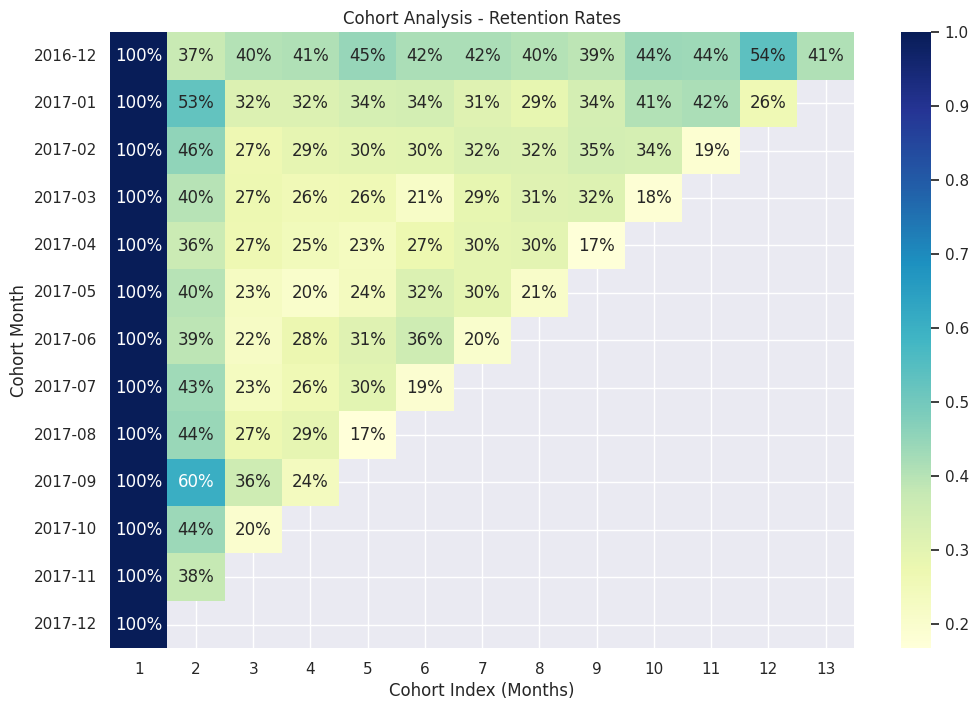

In [ ]:
df['Date'] = pd.to_datetime(df['Date of purchase'])              #  ??
df['Month'] = df['Date'].dt.to_period('M')
df['CohortMonth'] = df.groupby('CustomerID')['Date'].transform('min').dt.to_period('M')

def cohort_index(df):
    year_diff = df['Month'].dt.year - df['CohortMonth'].dt.year
    month_diff = df['Month'].dt.month - df['CohortMonth'].dt.month
    return year_diff * 12 + month_diff + 1

df['CohortIndex'] = cohort_index(df)

cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()

cohort_counts = cohort_data.pivot_table(index='CohortMonth', columns='CohortIndex', values='CustomerID')

# Retention Rate
cohort_sizes = cohort_counts.iloc[:,0]
retention = cohort_counts.divide(cohort_sizes, axis=0)

plt.figure(figsize=(12,8))
sns.heatmap(retention, annot=True, fmt='.0%', cmap='YlGnBu')
plt.title('Cohort Analysis - Retention Rates')
plt.ylabel('Cohort Month')
plt.xlabel('Cohort Index (Months)')
plt.show()

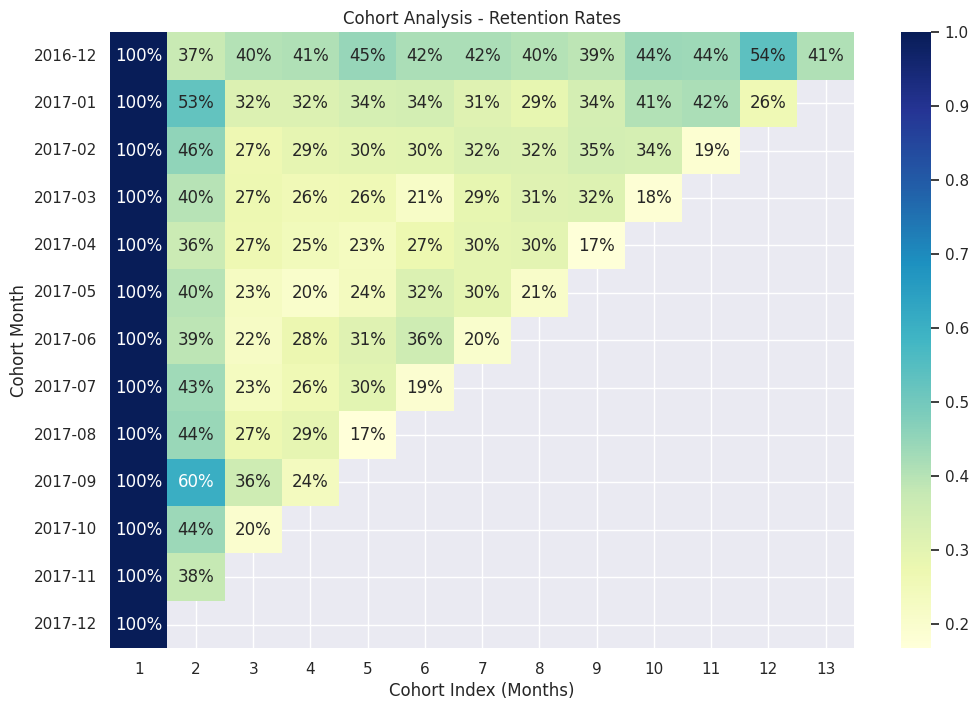

In [ ]:
def cohort_index(df):
    year_diff = df['Month'].dt.year - df['CohortMonth'].dt.year
    month_diff = df['Month'].dt.month - df['CohortMonth'].dt.month
    return year_diff * 12 + month_diff + 1

df['CohortIndex'] = cohort_index(df)

cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()

cohort_counts = cohort_data.pivot_table(index='CohortMonth', columns='CohortIndex', values='CustomerID')

# Retention Rate
cohort_sizes = cohort_counts.iloc[:,0]
retention = cohort_counts.divide(cohort_sizes, axis=0)

plt.figure(figsize=(12,8))
sns.heatmap(retention, annot=True, fmt='.0%', cmap='YlGnBu')
plt.title('Cohort Analysis - Retention Rates')
plt.ylabel('Cohort Month')
plt.xlabel('Cohort Index (Months)')
plt.show()

In [ ]:
df

,CustomerID,Item Code,InvoieNo,Date of purchase,Quantity,Time,price per Unit,Price,Shipping Location,Cancelled_status,Reason of return,Sold as set,Date,Month,CohortMonth,CohortIndex
0,4355.0,15734,398177.0,29-10-2017,6.0,3:36:00 PM,321.0,1926.0,Location 1,NaN,NaN,NaN,2017-10-29,2017-10,2017-09,2
1,4352.0,14616,394422.0,05-10-2017,2.0,2:53:00 PM,870.0,1740.0,Location 1,NaN,NaN,NaN,2017-10-05,2017-10,2017-02,9
2,4352.0,14614,394422.0,12-10-2017,2.0,2:53:00 PM,933.0,1866.0,Location 1,NaN,NaN,NaN,2017-10-12,2017-10,2017-02,9
3,4352.0,85014B,388633.0,22-08-2017,3.0,2:47:00 PM,623.0,1869.0,Location 1,NaN,NaN,NaN,2017-08-22,2017-08,2017-02,7
4,4352.0,15364,394422.0,10-10-2017,2.0,2:53:00 PM,944.0,1888.0,Location 1,NaN,NaN,NaN,2017-10-10,2017-10,2017-02,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,1
541112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,1
541113,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,1
541114,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,1
